# Data Splitting for QSAR
The data available to build a model are often split into multiple sets to avoid data leakage. The main reason for this is to evaluate the model's ability to predict unseen data: 
- training set (70-80%): Used to fit the model and set the model's parameters (automatically)
- validation set (10-15%): Used to evaluate different hyperparameters. Can be in form of cross-validation. 
- test set (10-15%): The final model is evaluated on the test set, to avoid overfitting during hyperparameter tuning. 

The most common approach is **random splitting**. Because compounds are often synthesized in series as close derivatives with shared scaffolds, random splitting very likely leads to compounds of the same series in all data sets. Thereby, an unrealistic scenario is created as the user is usually interested in predictions on novel scaffolds.

One approach is to split the compounds based on publication dates. This method is very effective when working with time-series to avoid the so-called look-ahead-bias. Here, we will split the data based on their Bemis-Murcko scaffolds in a way that all compounds sharing a scaffold can only be in one data set. 

# Setup Code
## Environment

In [1]:
### use brd4

import sys

print(sys.executable)

/home/oskar/anaconda3/envs/brd4/bin/python


## Imports

In [2]:
### Standard imports
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn as sk
from rdkit import RDLogger
from tqdm import tqdm

## Jupyter Settings

In [3]:
### Random seed - using the same seed for robustness
SEED = 42
np.random.seed(SEED)

### NumPy arrays - floats
np.set_printoptions(
    precision=2,  # round values
    suppress=True,
)  # avoid scientific notation

### pandas DataFrames
pd.set_option("display.float_format", "{:.3e}".format)  # Round to 2 decimal places

### Initialize tqdm for pandas
tqdm.pandas()

### Suppress RDKit logs
RDLogger.DisableLog("rdApp.*")

### Re-enable logging if needed
# RDLogger.EnableLog('rdApp.*')

## Utils
- [`utils/pd_mol.py`](../utils/pd_mol.py) contains individual functions for processing rdkit mol objects in pandas DataFrames. 
- The utility class [`MorganSimilarity`](../utils/similarity_sali.py) will be used to calculate Morgan fingerprints (features). 

In [4]:
### Add the utils directory to the path
sys.path.append(os.path.abspath("../utils"))

from pd_mol import render_mol
import pd_mol
from similarity_sali import MorganSimilarity
import similarity_sali 

# Data
To ensure reproducibility `01_brd4_all_inhibitors.pkl` generated [here](../01_eda/01_pre_process.ipynb) is used for this analysis. They are described by (columns):
- `ID`: string - unique identifier from `ChEMBL`
- `Mol`: rdkit.Chem.rdchem.Mol - standardized inhibitor structure 
- `pIC50`: float - quantitative activity (negative logarithm of the half maximal inhibitory concentration in `mol / L`). 
- `active`: float - 1.00 (active), 0.00 (inactive)

2920


,Mol,pIC50,active
ID,,,
CHEMBL1097107,,6.255e+00,NaN
CHEMBL1232461,,7.007e+00,1.000e+00
CHEMBL1233528,,6.922e+00,1.000e+00

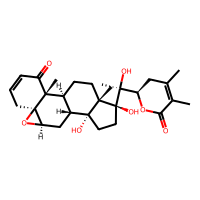
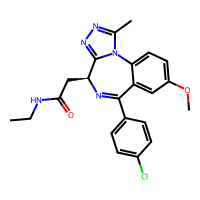
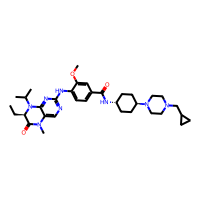

In [5]:
df = pd.read_pickle("../data/01_brd4_all_inhibitors.pkl")
df.set_index("ID", inplace=True)
print(len(df))
render_mol(df.head(3))

## Morgan Fingerprints
Throughout this repository Morgan fingerprints are used as molecular descriptors. It is common to generate 1024 or 2048 features and then simplify using dimensionality reduction techniques like PCA. [Here](../03_QSAR_classifier/01_feature_selection.ipynb) is demonstrated that 2048 fingerprints reduced to 32 features is a good compromise for this data set. The same approach is used here. 

In [6]:
### Create a class instance
morgan = MorganSimilarity(df, nBits=2048, radius=3)

### Generate Morgan fingerprints as list of bitvectors
morgan.get_morgan_fingerprint()

### Convert to DataFrame for inspection
X = morgan.format_fp('np_array')
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       ...,
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(2920, 2048))

## Data Splitting by Bemis-Murcko Scaffolds

A molecule's Bemis-Murcko scaffold is a simplified representation: [G. W. Bemis and M. A. Murcko, *J. Med. Chem*. **1996**, *39*, 15, 2887–2893](https://pubs.acs.org/doi/10.1021/jm9602928). Atoms and bonds are classified as:

- Fragments: One fragment is any kind of fused ring system. 
- Linkers: Bonds connecting fragments. 
- Side chains: Neither fragments or linkers. 

For this analysis:
- Side chains are stripped. 
- Bond orders are ignored.
- The element type of atoms are ignored. 

The utility function [`similarity_sali.get_bemis_murcko`](../utils/similarity_sali.py) generates the scaffolds from RDKit mol objects and assigns cluster IDs. 

In [7]:
### Bemis-Murcko clustering
df = similarity_sali.get_bemis_murcko(df, return_smiles=False, return_cluster=True)

MurckoScaffold.MakeScaffoldGeneric


100%|██████████| 2920/2920 [00:01<00:00, 2353.91it/s]


MurckoScaffold.GetScaffoldForMol


100%|██████████| 2920/2920 [00:00<00:00, 6341.81it/s]


largest_frag=False (rdMolStandardize.FragmentParent):
remove_charge=False (rdMolStandardize.Uncharger().uncharge):
tautomerize=False (rdMolStandardize.CanonicalTautomer)
normalize=True (rdMolStandardize.Normalize):


...

100%|██████████| 2920/2920 [00:00<00:00, 4094.71it/s]


cal_2D_coord_deep=False (rdCoordGen.AddCoords):
cleanup=True (rdMolStandardize.Cleanup):


100%|██████████| 2920/2920 [00:03<00:00, 955.85it/s]


Chem.MolToSmiles


100%|██████████| 2920/2920 [00:00<00:00, 8920.33it/s]


,Mol,pIC50,active,BM_mol,BM_cluster
ID,,,,,
CHEMBL5090895,,4.120e+00,0.000e+00,,565
CHEMBL5172189,,6.413e+00,NaN,,579
CHEMBL4878894,,5.471e+00,0.000e+00,,541

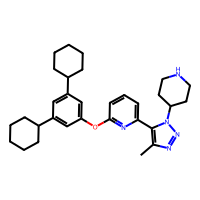
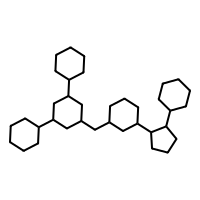
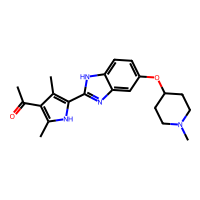
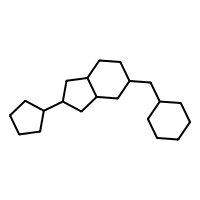
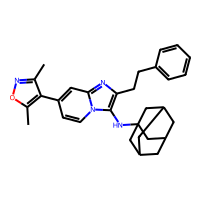
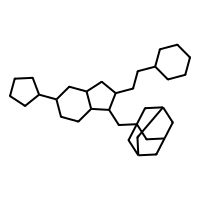

In [8]:
### Visual inspection
render_mol(df.sample(3))

**Test Set**

Single splits can be performed using `sklearn.model_selection.GroupShuffleSplit`

In [9]:
### Instantiate data splitter
gss = sk.model_selection.GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)

### Split the data into train and test sets without splitting Bemis-Murcko clusters
train_idx, test_idx = next(gss.split(df, df['pIC50'], groups=df['BM_cluster']))


`BM_cluster`s are separated without overlap. 

In [10]:
### Bemis-Murcko test clusters
test_BM_clusters = df.iloc[test_idx]['BM_cluster'].to_numpy()

### Bemis-Murcko train clusters
train_BM_clusters = df.iloc[train_idx]['BM_cluster'].to_numpy()

### Check for overlap
pd.Series(test_BM_clusters).isin(train_BM_clusters).any()


np.False_

In [11]:
### Split features
X_train_BM = X[train_idx]
X_test_BM = X[test_idx]

### Split targets
y_train_BM = df.iloc[train_idx]['pIC50'].to_numpy()
y_test_BM = df.iloc[test_idx]['pIC50'].to_numpy()

### Check shapes
print("features:", X.shape, X_train_BM.shape, X_test_BM.shape)
print("targets:", y_train_BM.shape, y_test_BM.shape)

features: (2920, 2048) (2562, 2048) (358, 2048)
targets: (2562,) (358,)


# KNN Regression with PCA
Grouped data splitters like `sklearn.model_selection.GroupKFold` are perfectly compatible with `sklearn.model_selection.cross_validate` or `sklearn.model_selection.cross_val_score`. However, to avoid data leakage the PCA model needs to fitted for every fold. To avoid refitting the PCA model for the same fold when testing different hyperparameters the custom function `cross_val_pca` is used.

Grouped data splitting using Bemis-Murcko scaffolds and random splitting is compared. 


In [12]:
def cross_val_pca(data_splitter, groups, split):
    """
    Run PCA and KNN regression with given splitter.
    """
    
    ### Instantiate DataFrame to store results
    results_df = pd.DataFrame()

    ### Verbose
    print(f"PCA and KNN with {split} splitting")

    ### Cross validation loop
    for train_idx, val_idx in data_splitter.split(X_train_BM, y_train_BM, groups=groups):
        
        ### Instantiate PCA
        pca = sk.decomposition.PCA(n_components=n_components)
        
        ### Fit PCA on training data and generate training features
        X_train = pca.fit_transform(X_train_BM[train_idx])

        ### Generate validation features
        X_val = pca.transform(X_train_BM[val_idx])

        ### Loop over number of neighbors
        for k in tqdm(ks):
            ### Run KNN and get errors
            errors_df = _run_knn(X_train, X_val, y_train_BM[train_idx], y_train_BM[val_idx], k)

            ### Append results to DataFrame
            results_df = pd.concat([results_df, errors_df], ignore_index=True)
    
    ### Add split information
    results_df['split'] = split

    ### Return results
    return results_df


def _run_knn(X_train, X_val, y_train, y_val, k):
    """
    Helper function: Run KNN regression and return train and validation RMSEs.
    """

    ### Instantiate regressor
    knn = sk.neighbors.KNeighborsRegressor(
        n_neighbors=k,
        metric="minkowski", 
        n_jobs=-1,
    )
    ### Train the model
    knn.fit(X_train, y_train)

    ### Calculate train and validation RMSEs
    train_error = sk.metrics.root_mean_squared_error(knn.predict(X_train), y_train)
    val_error   = sk.metrics.root_mean_squared_error(knn.predict(X_val), y_val)
    
    ### Create a DataFrame with the errors
    errors_df = pd.DataFrame({
        'RMSE': [train_error, val_error],
        'error_type': ['train', 'val'],
        'k': [k, k],
    })
    ### Return errors
    return errors_df


In [13]:

### List of number of neighbors
ks = [1, 2, 3, 4, 5, 7, 9, 15, 25] 

### Number of PCA components
n_components = 32

### Number of folds
n_folds = 10

### Instantiate grouped data splitter
grouped_splitter = sk.model_selection.GroupKFold(n_splits=n_folds, shuffle=True, random_state=SEED)

### Cross validation with grouped splitter
BM_results_df = cross_val_pca(grouped_splitter, train_BM_clusters, 'grouped')

### Instantiate random data splitter
random_splitter = sk.model_selection.KFold(n_splits=n_folds, shuffle=True, random_state=SEED)

### Cross validation with random splitter
rand_results_df = cross_val_pca(random_splitter, None, 'random')

### Concatenate results
results_df = pd.concat([BM_results_df, rand_results_df], ignore_index=True)

PCA and KNN with grouped splitting


100%|██████████| 9/9 [00:00<00:00, 29.70it/s]


PCA and KNN with random splitting


100%|██████████| 9/9 [00:00<00:00, 30.74it/s]


<Figure size 1000x600 with 0 Axes>

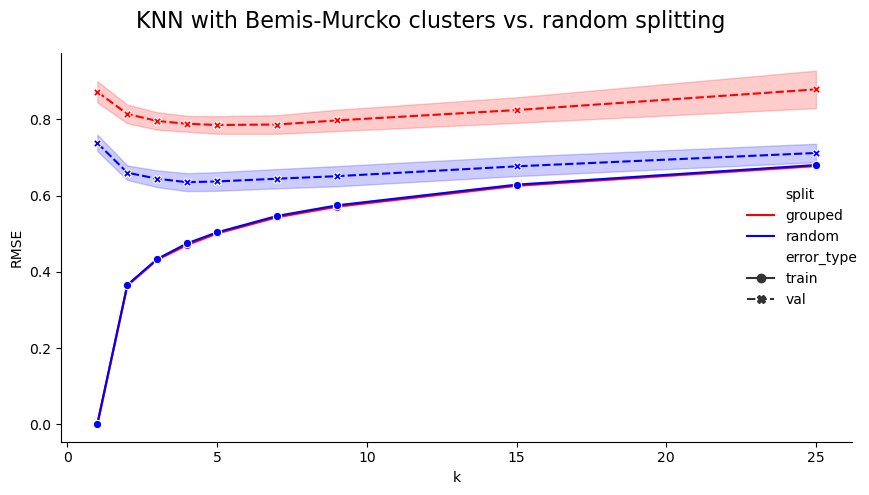

In [14]:
### Plot
plt.figure(figsize=(10, 6))
sns.relplot(
    data=results_df,
    x="k",
    y="RMSE",
    style="error_type",
    hue="split",
    kind="line",
    height=5,
    aspect=1.5,
    palette=["#FF0000", "#0000FF"],
    errorbar="se",
    markers=True
)
plt.suptitle("KNN with Bemis-Murcko clusters vs. random splitting", fontsize=16)
plt.subplots_adjust(top=0.85)
plt.tight_layout()
plt.show()

## Test Error

In [15]:
### Chosen hyperparameter
k = 5

### Instantiate regressor
knn = sk.neighbors.KNeighborsRegressor(
    n_neighbors=k,
    metric="minkowski", 
    n_jobs=-1,
)
### Train the model
knn.fit(X_train_BM, y_train_BM)

### Calculate train and validation RMSEs
print(f"train RMSE: {sk.metrics.root_mean_squared_error(knn.predict(X_train_BM), y_train_BM):.3f}")
print(f" test RMSE: {sk.metrics.root_mean_squared_error(knn.predict(X_test_BM), y_test_BM):.3f}")


train RMSE: 0.476
 test RMSE: 0.714


# Conclusions
The lineplot "KNN with Bemis-Murcko clusters vs. random splitting" shows a clear gap between the validation scores for each k when using grouped or random data splitting. Demonstrating the fact that random data splitting leads to overly optimistic validation and test scores. The fact that the training errors are independent of the splitting methods and grouped train errors are therefore almost identical to random train errors was expected.  

The plot shows clear over-fitting for `k < 3` and clear under-fitting for `k > 10`. This is also independet of the splitting method. To select `k` the minimum cross-validation error (using grouped splitting) was the main factor. `k = 5` was chosen, because the difference in error between `k = 1` and `k = 5` is negligible, whereas the train-val-gap stabilizes for higher `k`.

The finally obtained test error reinforces that choice. The training error for the entire training set as well as the test RMSE are in the expected ranges for `k = 5`. 